# Time Series Enrichment Analysis
This notebook performs time-series clustering on normalized expression data and runs functional enrichment (GO/KEGG) on the identified clusters.

In [10]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gseapy as gp
from sklearn.cluster import KMeans
from scipy import stats
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import math
import warnings
import glob
import os

warnings.filterwarnings('ignore')
%matplotlib inline


## 1. Load Data
We load the **normalized counts** (output from pipeline) and **metadata**.

In [11]:

# Load Normalized Counts
counts_path = 'output/normalized_counts_for_plotting.csv'
try:
    norm_counts = pd.read_csv(counts_path, index_col=0)
    print(f"Loaded counts matrix: {norm_counts.shape}")
except FileNotFoundError:
    print(f"File not found: {counts_path}. Please ensure the pipeline has been run.")

# Load Metadata
# Try to find the metadata file dynamically
metadata_files = glob.glob('input/*export.csv')
if metadata_files:
    metadata_path = metadata_files[0] # Use the first found export file
    print(f"Using metadata file: {metadata_path}")
else:
    metadata_path = 'input/metadata.csv' # Fallback
    print(f"Using default metadata path: {metadata_path}")

try:
    metadata = pd.read_csv(metadata_path, index_col=0)
    print(f"Loaded metadata: {metadata.shape}")
except FileNotFoundError:
    print(f"File not found: {metadata_path}")


Loaded counts matrix: (53923, 28)
Using metadata file: input/2025-12-16T12-26_export.csv
Loaded metadata: (28, 4)


## 2. Helper Functions
Logic to prepare data for clustering (handling 0h timepoint and replicates).

In [12]:

def _get_timeseries_data_for_clustering(norm_counts, metadata, top_n=200, time_col='Time'):
    # Select treatment samples AND Control samples (for 0h timepoint)
    treat_samples = metadata[metadata['Type'].isin(['Treat', 'Control'])].index
    
    # Filter for samples present in count matrix
    valid_samples = [s for s in treat_samples if s in norm_counts.columns]
    treat_counts = norm_counts[valid_samples]
    treat_meta = metadata.loc[valid_samples]

    # Average replicates based on time column
    if time_col not in treat_meta.columns:
        print(f"Warning: Time column '{time_col}' not found. Using 'Time' or first available.")
        time_col = 'Time' if 'Time' in treat_meta.columns else treat_meta.columns[0]
    
    # Calculate Mean per Time Point
    time_avg_counts = treat_counts.T.groupby(treat_meta[time_col]).mean().T
    
    if time_avg_counts.shape[1] < 2:
        print("Not enough time points for analysis.")
        return None
    
    # Select Top N Variable Genes
    top_genes = time_avg_counts.var(axis=1).nlargest(top_n).index
    plot_data = time_avg_counts.loc[top_genes]

    # Z-score Standardization
    zscore_data = pd.DataFrame(stats.zscore(plot_data, axis=1, nan_policy='omit'), 
                               index=plot_data.index, 
                               columns=plot_data.columns)
    zscore_data = zscore_data.fillna(0)
    
    return zscore_data, top_genes


## 3. Time Series Clustering
Perform K-Means clustering and visualize the trends.

Selected 10000 genes for clustering.


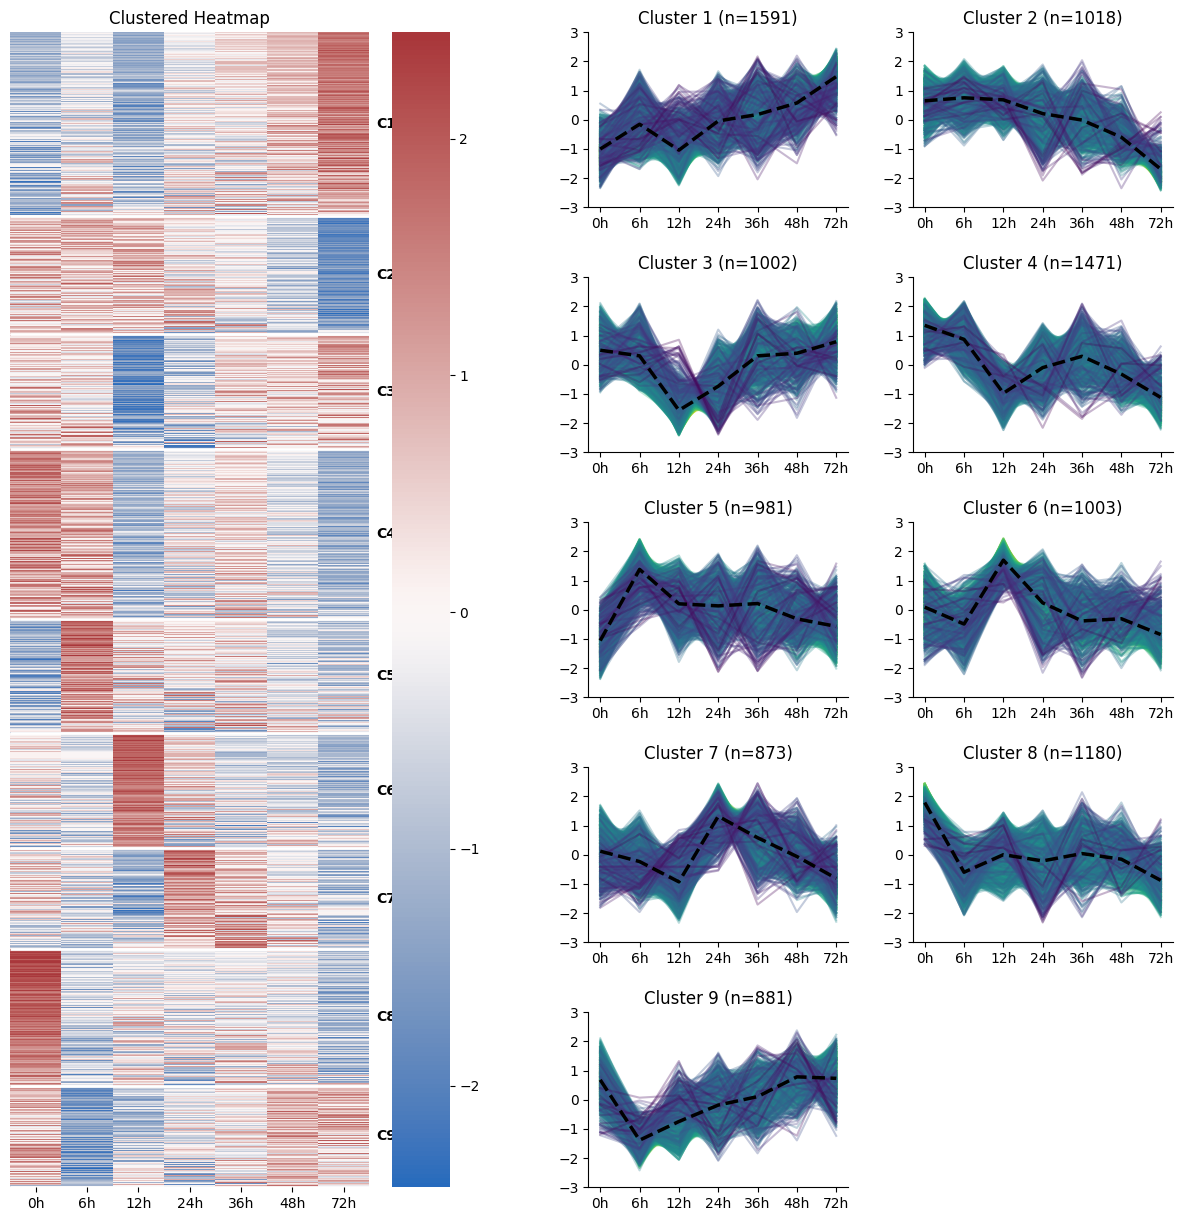

In [13]:

# Configuration
N_CLUSTERS = 9
TOP_N_GENES = 10000

# Prepare Data
zscore_data, selected_genes = _get_timeseries_data_for_clustering(norm_counts, metadata, top_n=TOP_N_GENES)
print(f"Selected {len(selected_genes)} genes for clustering.")

# Reorder columns chronologically
try:
    sorted_cols = sorted(zscore_data.columns, key=lambda x: float(x))
    is_numeric = True
except:
    sorted_cols = sorted(zscore_data.columns)
    is_numeric = False

zscore_data = zscore_data[sorted_cols]
time_points = [f"{t}h" if is_numeric else str(t) for t in sorted_cols]
zscore_data.columns = time_points

# Run K-Means
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
clusters = kmeans.fit_predict(zscore_data)
zscore_data['Cluster'] = clusters

# Calculate Membership (Distance to Centroid)
membership = []
for i in range(N_CLUSTERS):
    cluster_indices = zscore_data[zscore_data['Cluster'] == i].index
    cluster_data_numeric = zscore_data.loc[cluster_indices, time_points]
    
    if not cluster_data_numeric.empty:
        centroid = kmeans.cluster_centers_[i]
        distances = np.linalg.norm(cluster_data_numeric.values - centroid, axis=1)
        
        min_dist, max_dist = distances.min(), distances.max()
        if max_dist == min_dist:
            norm_mem = np.ones_like(distances)
        else:
            norm_mem = 1 - (distances - min_dist) / (max_dist - min_dist)
            
        for g, score in zip(cluster_indices, norm_mem):
            membership.append({'gene': g, 'membership': score})

mem_df = pd.DataFrame(membership).set_index('gene')
zscore_data = zscore_data.merge(mem_df, left_index=True, right_index=True, how='left').fillna(0)

# Sort for Heatmap
zscore_data = zscore_data.sort_values(by=['Cluster', 'membership'], ascending=[True, False])

# Visualization
n_cols = 2
n_rows = math.ceil(N_CLUSTERS / n_cols)
fig = plt.figure(figsize=(15, max(8, 3*n_rows)))

gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.3], wspace=0.25)

# Heatmap
ax_hm = fig.add_subplot(gs[0, 0])
sns.heatmap(zscore_data[time_points], ax=ax_hm, cmap='vlag', center=0, cbar=True, yticklabels=False)
ax_hm.set_title("Clustered Heatmap")

# Add Cluster Labels
y_pos = 0
for i in range(N_CLUSTERS):
    count = (zscore_data['Cluster'] == i).sum()
    if count > 0:
        ax_hm.text(len(time_points)*1.02, y_pos + count/2, f"C{i+1}", va='center', fontweight='bold')
        ax_hm.hlines(y_pos + count, *ax_hm.get_xlim(), colors='white', lw=2)
        y_pos += count

# Trend Plots
gs_trends = gs[0, 1].subgridspec(n_rows, n_cols, hspace=0.4, wspace=0.25)
cmap = plt.get_cmap('viridis')

for i in range(N_CLUSTERS):
    r, c = divmod(i, n_cols)
    ax = fig.add_subplot(gs_trends[r, c])
    
    subset = zscore_data[zscore_data['Cluster'] == i]
    if not subset.empty:
        # Individual Lines
        for _, row in subset.iterrows():
            ax.plot(time_points, row[time_points], color=cmap(row['membership']), alpha=0.3)
        # Mean Line
        ax.plot(time_points, subset[time_points].mean(), color='black', lw=2.5, ls='--')
        
    ax.set_title(f"Cluster {i+1} (n={len(subset)})")
    ax.set_ylim(-3, 3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.show()


## 4. Cluster Enrichment Analysis
Run GO information and KEGG pathways enrichment for each cluster using `gseapy`.


Processing Cluster 0...


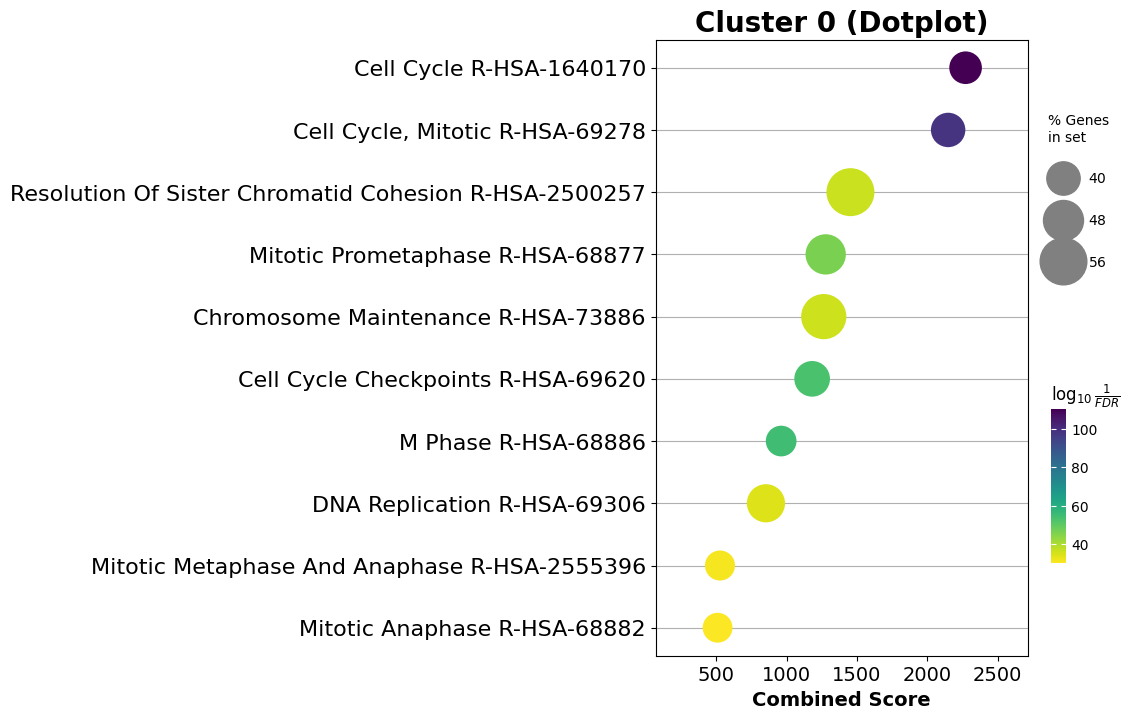

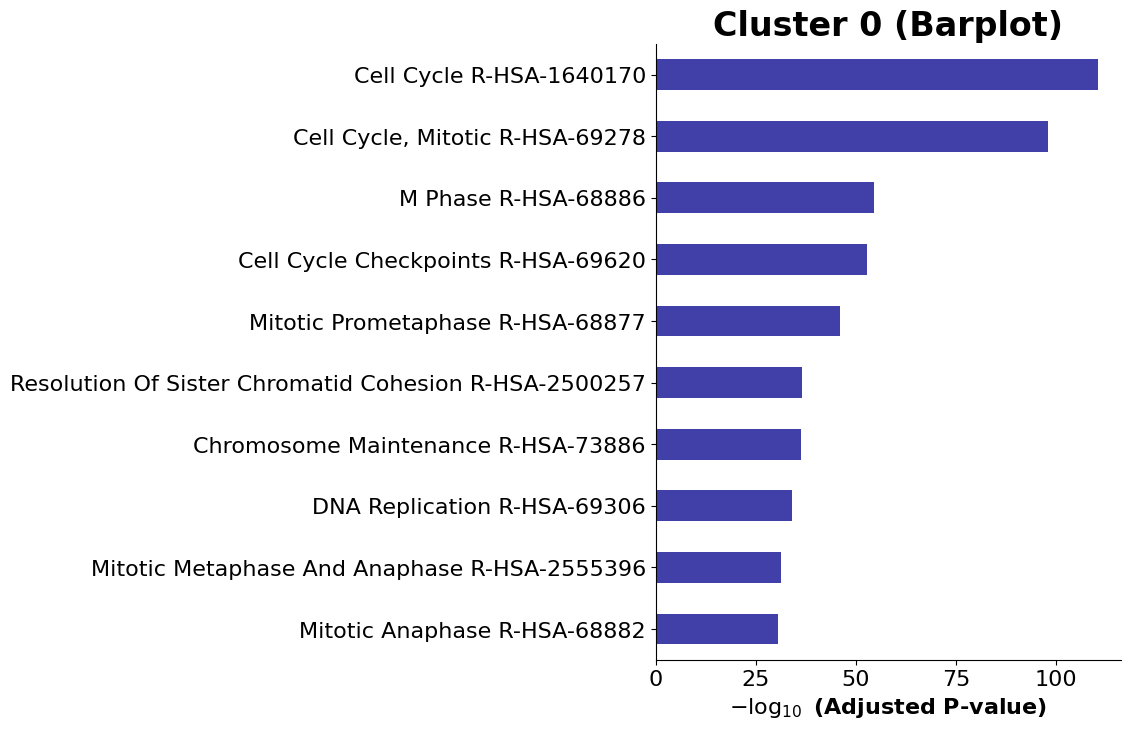


Processing Cluster 1...
Dotplot error: Warning: No enrich terms when cutoff = 0.05
Barplot error: Warning: No enrich terms when cutoff = 0.05

Processing Cluster 2...
Dotplot error: Warning: No enrich terms when cutoff = 0.05
Barplot error: Warning: No enrich terms when cutoff = 0.05

Processing Cluster 3...
Dotplot error: Warning: No enrich terms when cutoff = 0.05
Barplot error: Warning: No enrich terms when cutoff = 0.05

Processing Cluster 4...


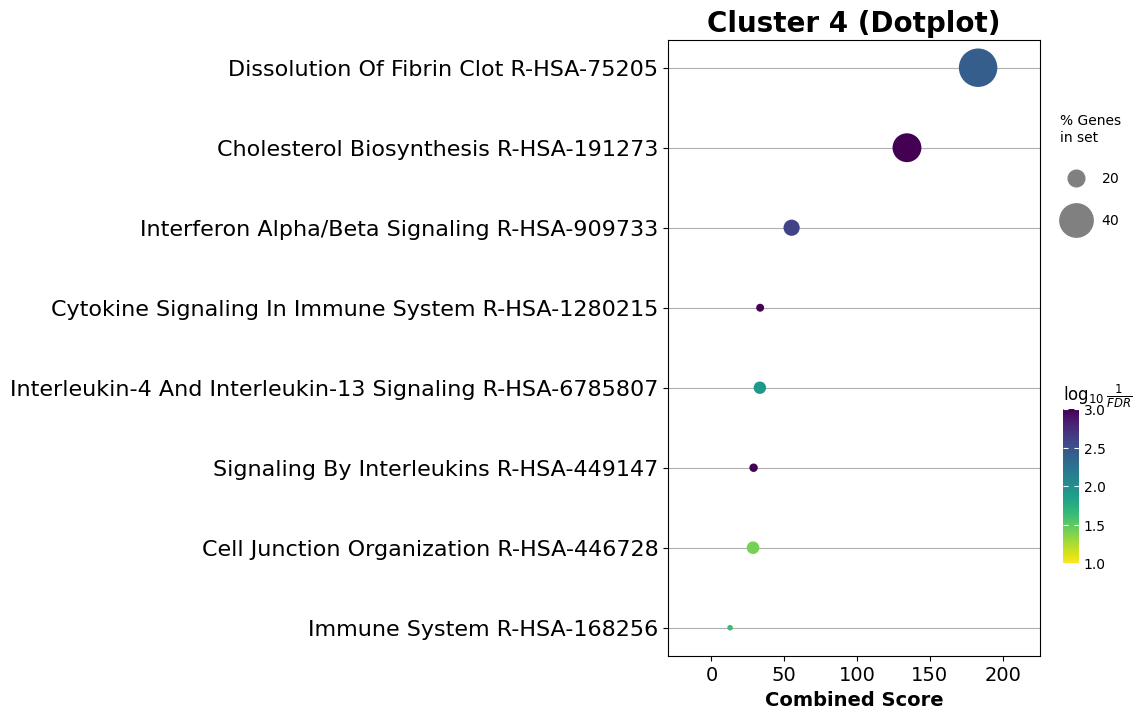

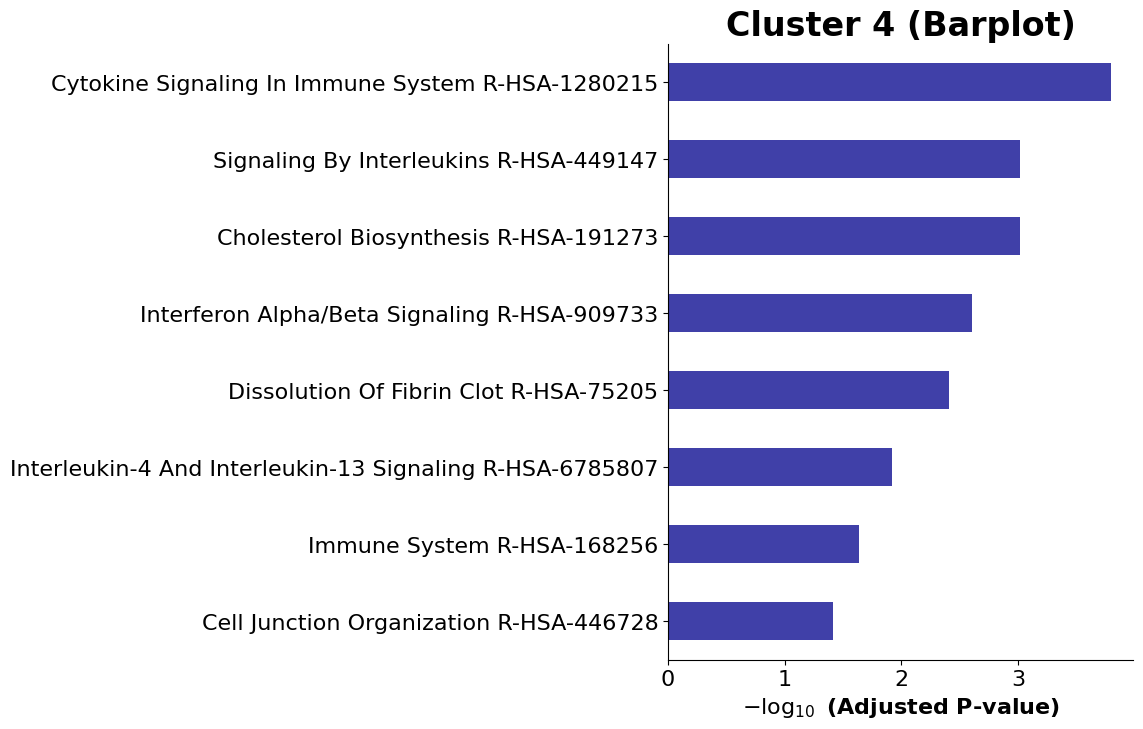


Processing Cluster 5...
Dotplot error: Warning: No enrich terms when cutoff = 0.05
Barplot error: Warning: No enrich terms when cutoff = 0.05

Processing Cluster 6...
Dotplot error: Warning: No enrich terms when cutoff = 0.05
Barplot error: Warning: No enrich terms when cutoff = 0.05

Processing Cluster 7...
Dotplot error: Warning: No enrich terms when cutoff = 0.05
Barplot error: Warning: No enrich terms when cutoff = 0.05

Processing Cluster 8...


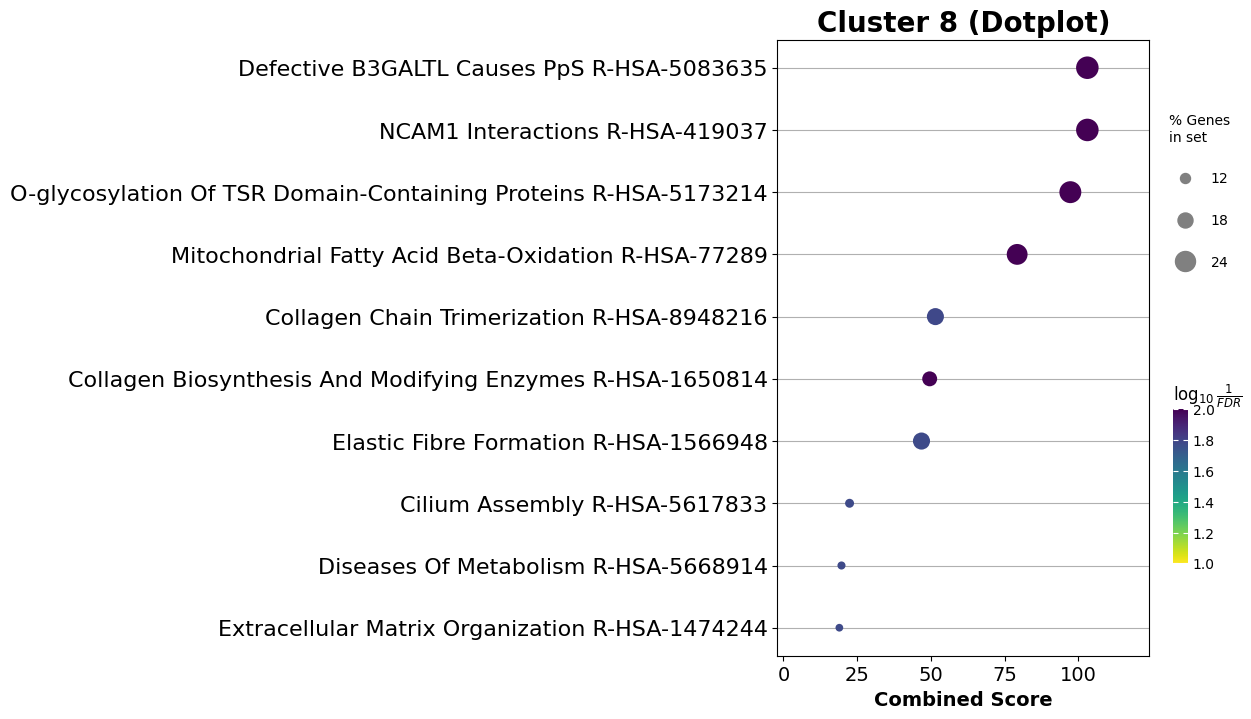

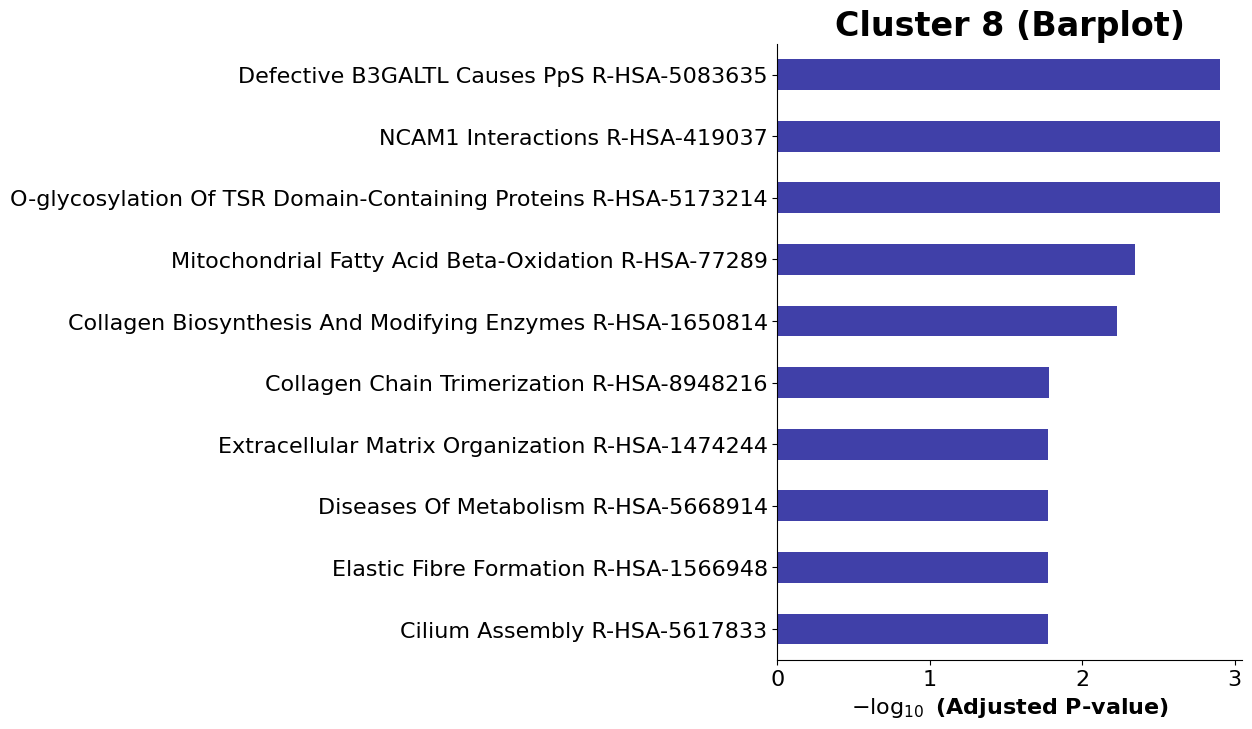

In [14]:

# Run Enrichment
results = {}
species = 'Mouse' # Configured species
gene_sets = ['GO_Biological_Process_2023', 'KEGG_2019_Mouse', 'Reactome_2022']

unique_clusters = sorted(zscore_data['Cluster'].unique())

for cluster_id in unique_clusters:
    print(f"\nProcessing Cluster {cluster_id}...")
    # Use zscore_data to get genes for the cluster
    genes = zscore_data[zscore_data['Cluster'] == cluster_id].index.tolist()
    
    if len(genes) < 5:
        print("  Skipping: Too few genes.")
        continue
        
    try:
        enr = gp.enrichr(gene_list=genes,
                         gene_sets=gene_sets,
                         organism=species,
                         outdir=None) # Don't write to disk
        
        results[cluster_id] = enr
        
        # Filter for significant results for plotting
        if enr.results.shape[0] == 0:
             print(" No enrichment found.")
             continue
             
        # Dotplot
        try:
            ax = gp.dotplot(enr.res2d, title=f'Cluster {cluster_id} (Dotplot)',
                            cmap='viridis_r', size=10, figsize=(6,8))
            plt.show()
        except Exception as e:
            print(f"Dotplot error: {e}")
        
        # Barplot
        try:
            ax = gp.barplot(enr.res2d, title=f'Cluster {cluster_id} (Barplot)',
                            color='darkblue', figsize=(6,8))
            plt.show()
        except Exception as e:
             print(f"Barplot error: {e}")
        
    except Exception as e:
        print(f"  Enrichment failed: {e}")

